In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution_V0 as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [4]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [5]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['CO_MG'] = data['CO_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['CO_FE'] = data['CO_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['CU_MG'] = data['CU_H_BAWLAS_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['CU_FE'] = data['CU_H_BAWLAS_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

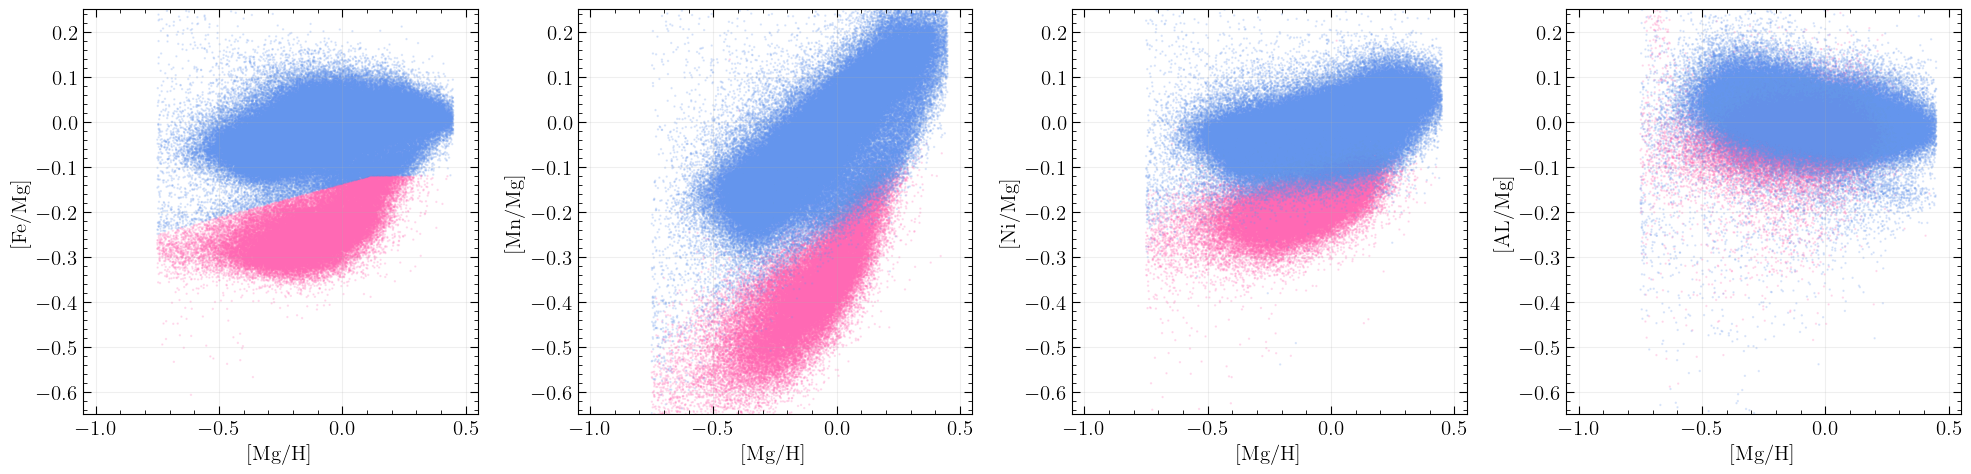

In [6]:
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()


plt.subplot(1,4,2)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)


plt.subplot(1,4,3)
plt.scatter(data['MG_H'], data['NI_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Ni/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)



plt.subplot(1,4,4)
plt.scatter(data['MG_H'], data['AL_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[AL/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)


plt.tight_layout()

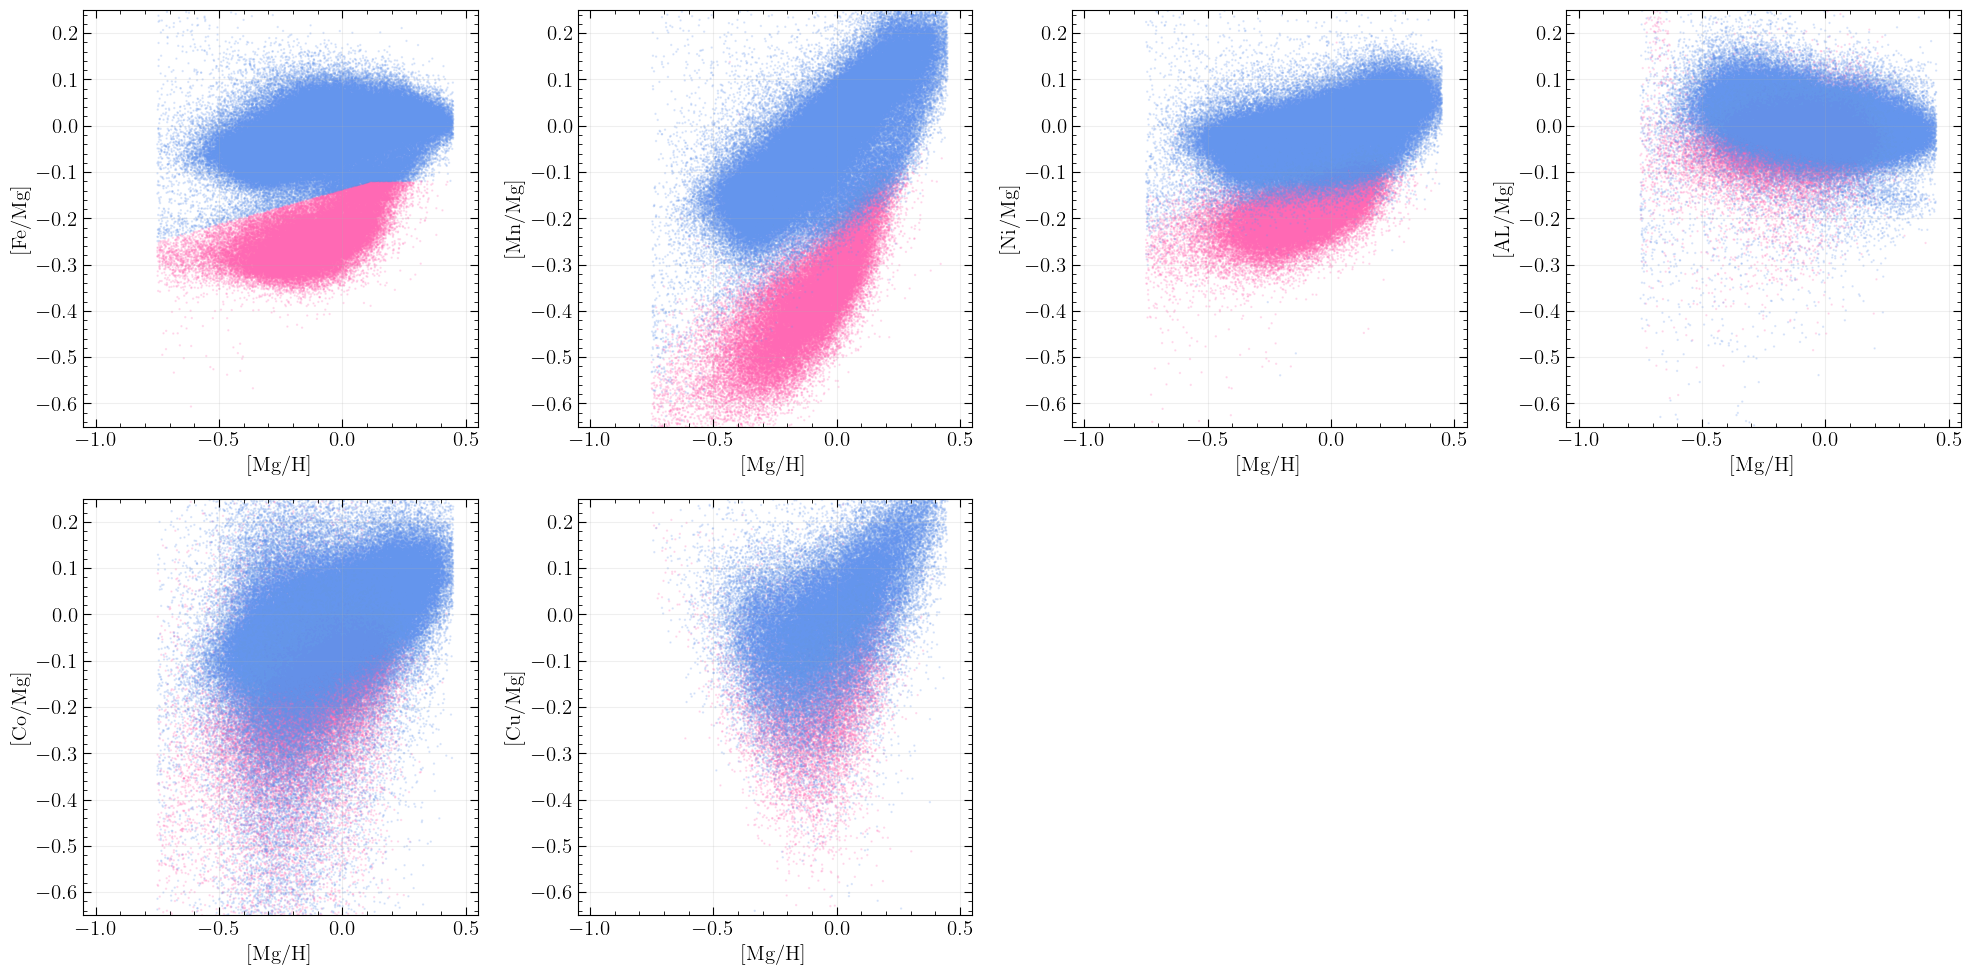

In [7]:
plt.figure(figsize=(20,10))
plt.subplot(2,4,1)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()


plt.subplot(2,4,2)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)


plt.subplot(2,4,3)
plt.scatter(data['MG_H'], data['NI_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Ni/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)



plt.subplot(2,4,4)
plt.scatter(data['MG_H'], data['AL_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[AL/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)

plt.subplot(2,4,5)
plt.scatter(data['MG_H'], data['CO_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Co/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)

plt.subplot(2,4,6)
plt.scatter(data['MG_H'], data['CU_MG'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Cu/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)



plt.tight_layout()

(-0.65, 0.25)

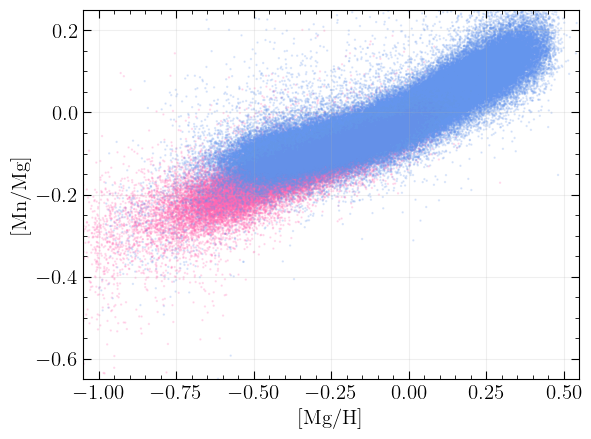

In [8]:
plt.scatter(data['FE_H'], data['MN_FE'], alpha = 0.2, color = data['color'], s = 0.5)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.ylim(-0.65,0.25)

In [ ]:
mg_h_bin_edges = np.arange(-0.6, 0.3, 0.1) 
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2) 

data['MG_H_bin'] = pd.cut(data['MG_H'], bins = mg_h_bin_edges, right=False, labels=False)
data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]

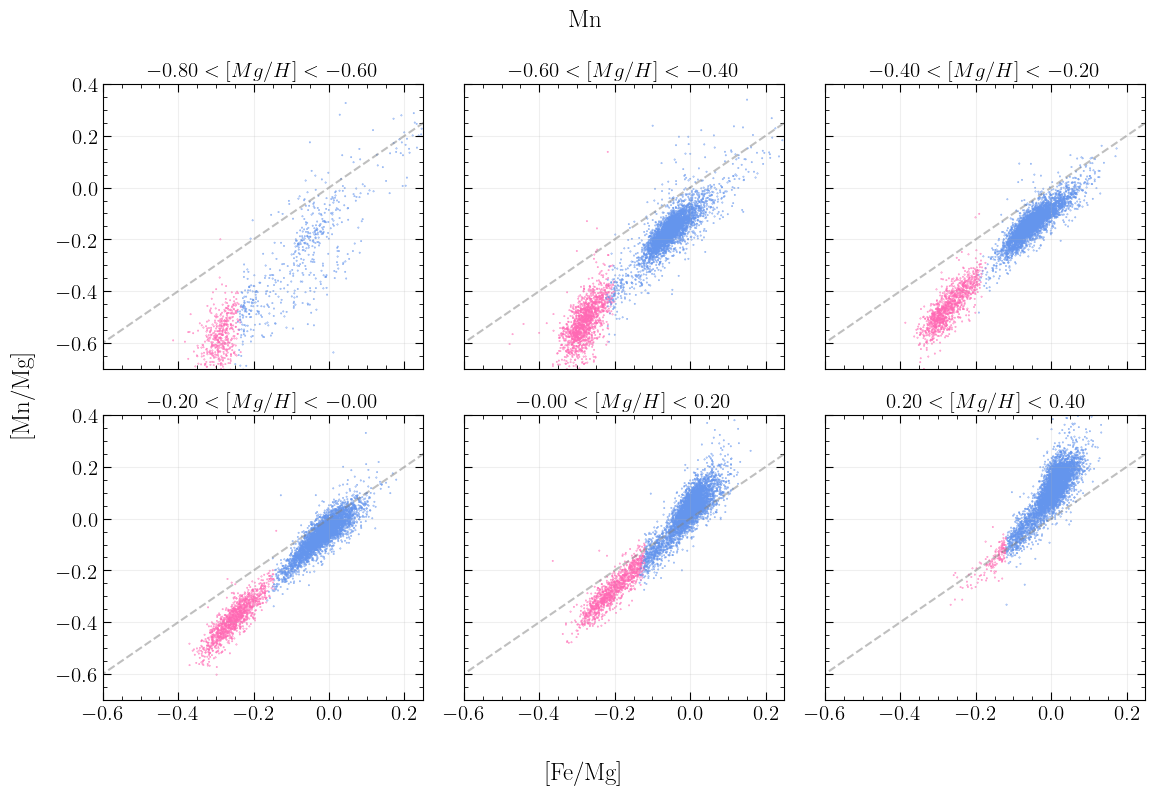

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    bin_index = i + 1
    df = data[data['MG_H_big_bin'] == bin_index]
    df = downsample(df, 5000)

    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', color='gray', alpha=0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[bin_index]:.2f} < [Mg/H] < {mg_h_big_bin_edges[bin_index+1]:.2f}$'
    )

    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle("Mn")
plt.tight_layout()
plt.show()

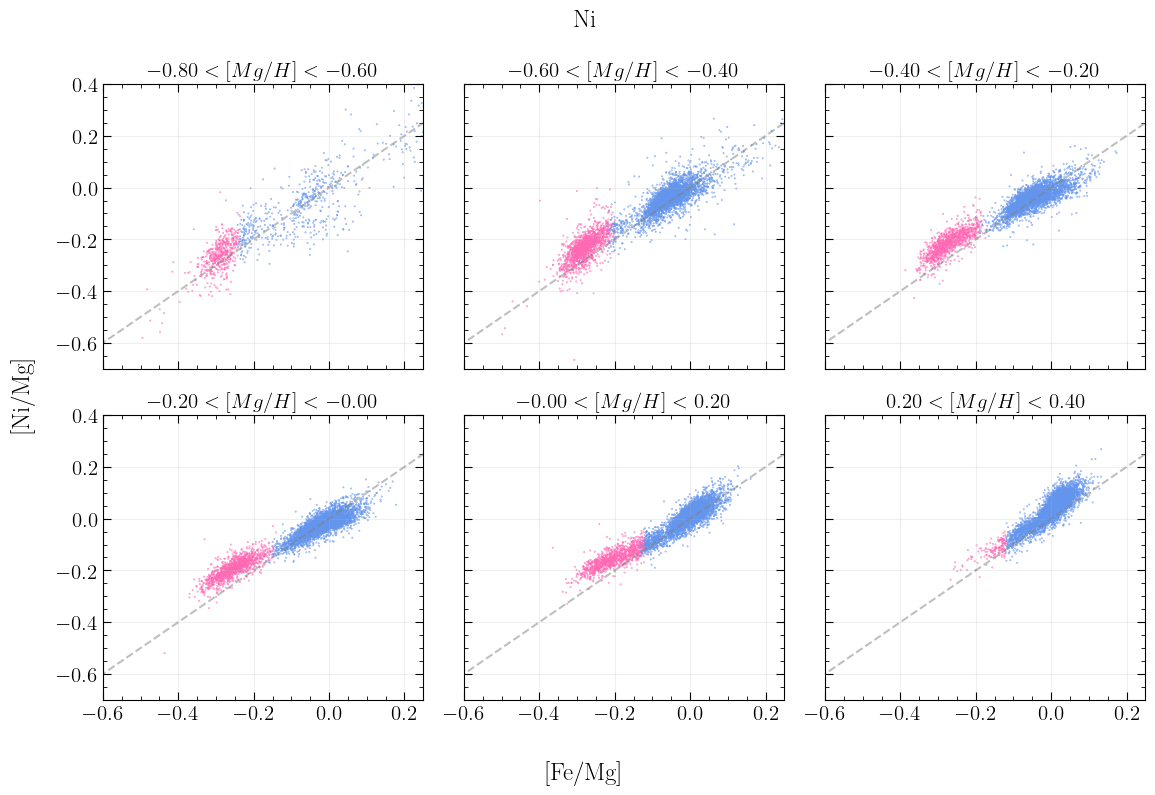

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    bin_index = i + 1
    df = data[data['MG_H_big_bin'] == bin_index]
    df = downsample(df, 5000)

    ax.scatter(df['FE_MG'], df['NI_MG'], s=0.1, color=df['color'])

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', color='gray', alpha=0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[bin_index]:.2f} < [Mg/H] < {mg_h_big_bin_edges[bin_index+1]:.2f}$'
    )

    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Ni/Mg]')
fig.suptitle("Ni")
plt.tight_layout()
plt.show()

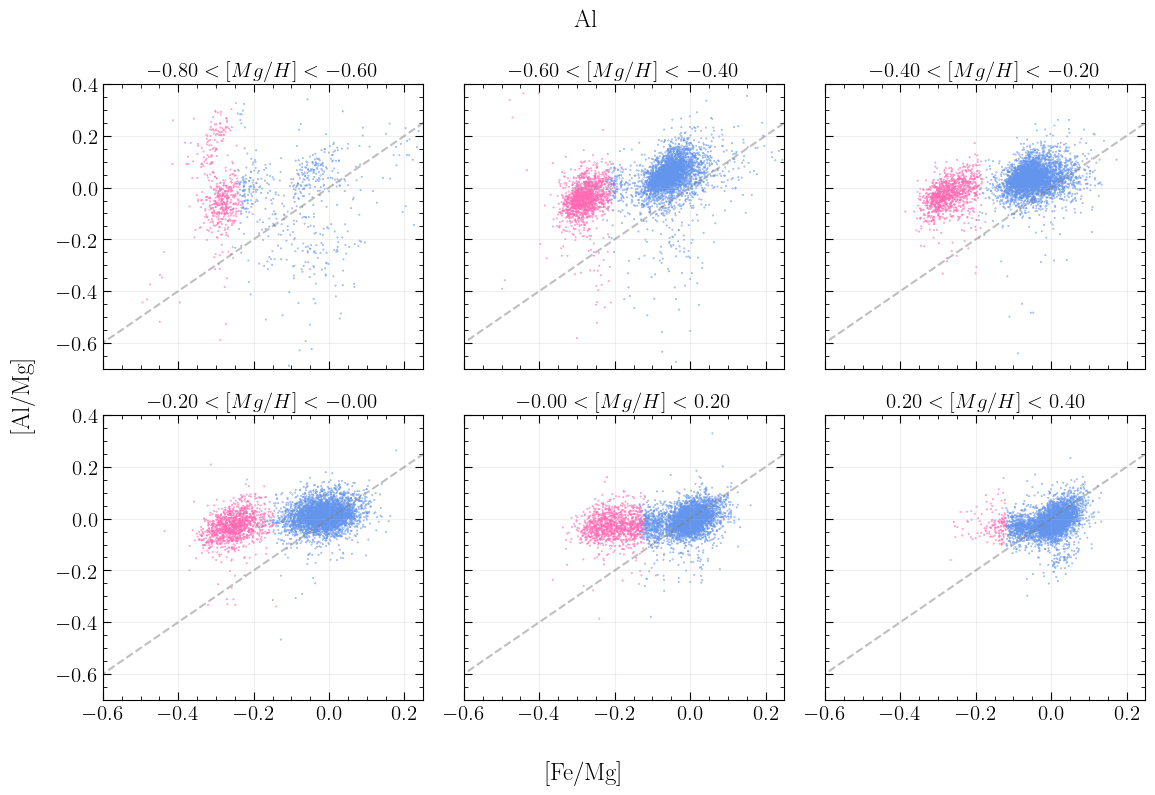

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    bin_index = i + 1
    df = data[data['MG_H_big_bin'] == bin_index]
    df = downsample(df, 5000)

    ax.scatter(df['FE_MG'], df['AL_MG'], s=0.1, color=df['color'])

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', color='gray', alpha=0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[bin_index]:.2f} < [Mg/H] < {mg_h_big_bin_edges[bin_index+1]:.2f}$'
    )

    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Al/Mg]')
fig.suptitle("Al")
plt.tight_layout()
plt.show()

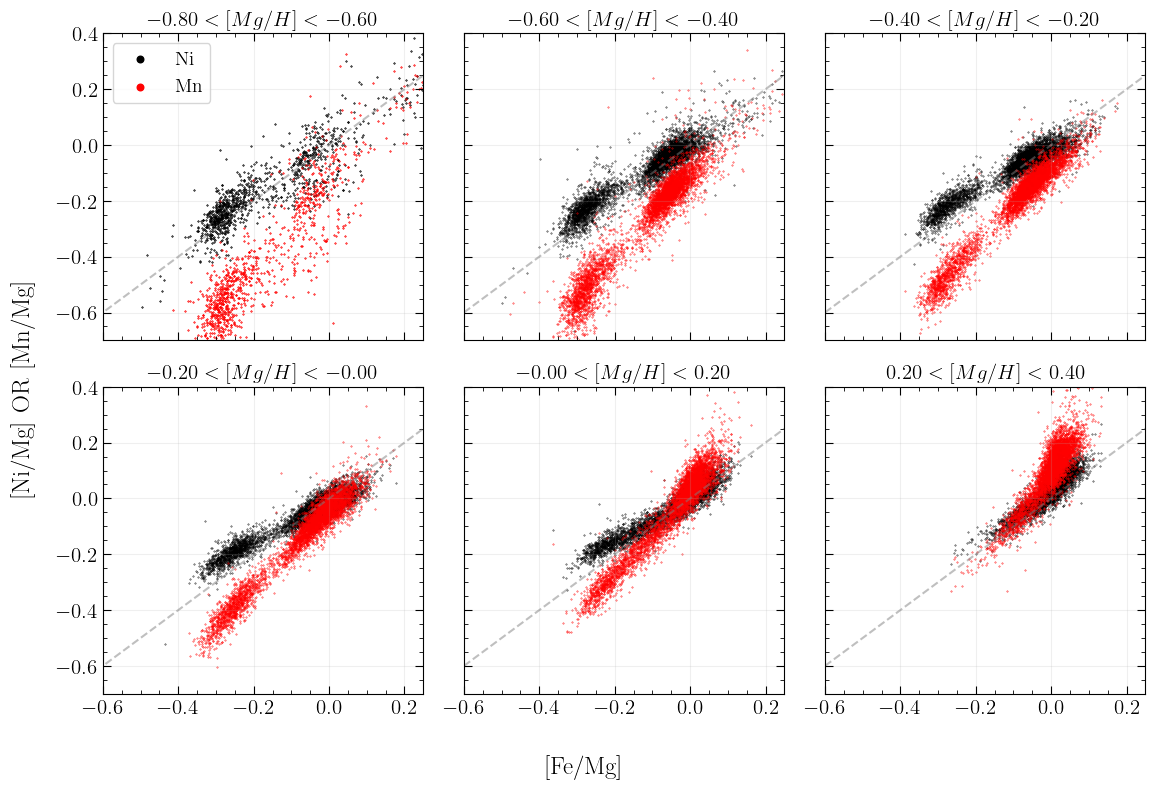

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    bin_index = i + 1
    df = data[data['MG_H_big_bin'] == bin_index]
    df = downsample(df, 5000)

    if i == 0:
        ax.scatter(df['FE_MG'], df['NI_MG'], s=0.1, color='black', label = 'Ni')
        ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color = 'red', label = 'Mn')
        ax.legend(markerscale = 15)

    ax.scatter(df['FE_MG'], df['NI_MG'], s=0.1, color='black')
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color = 'red')

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', color='gray', alpha=0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[bin_index]:.2f} < [Mg/H] < {mg_h_big_bin_edges[bin_index+1]:.2f}$'
    )

    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Ni/Mg] OR [Mn/Mg]')
plt.tight_layout()
plt.show()

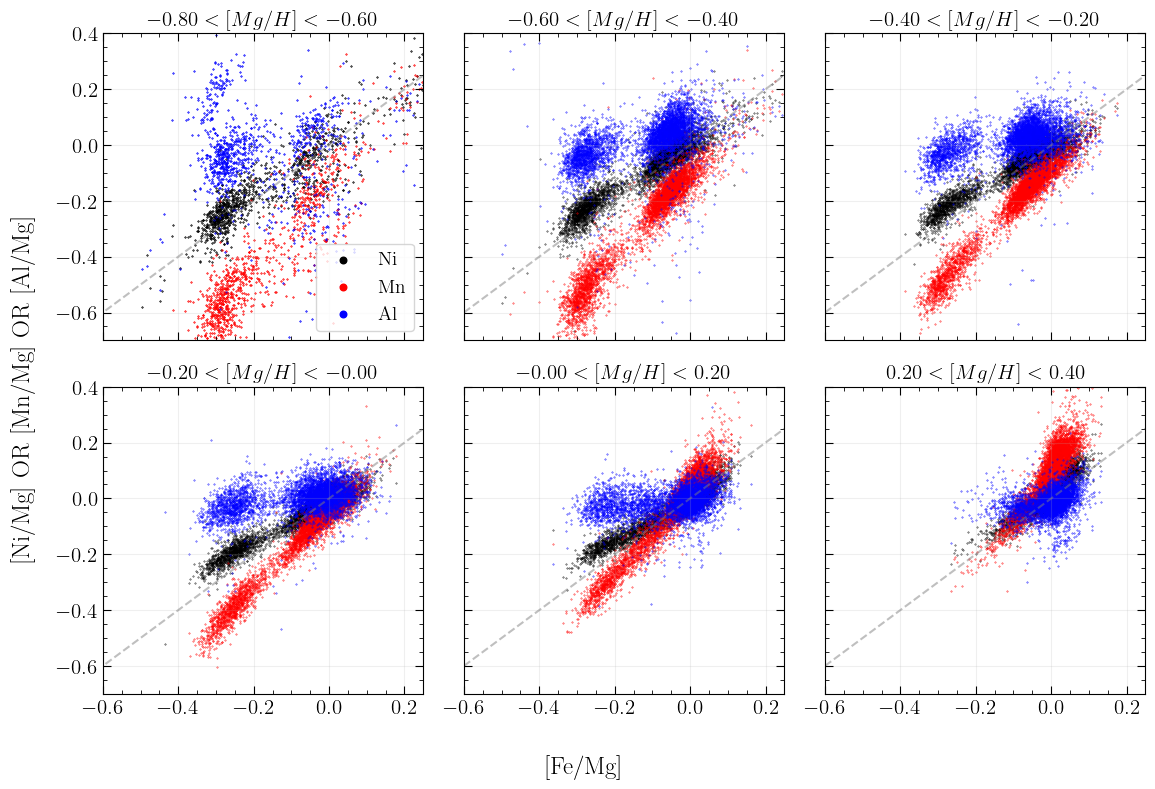

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    bin_index = i + 1
    df = data[data['MG_H_big_bin'] == bin_index]
    df = downsample(df, 5000)

    if i == 0:
        ax.scatter(df['FE_MG'], df['NI_MG'], s=0.1, color='black', label = 'Ni')
        ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color = 'red', label = 'Mn')
        ax.scatter(df['FE_MG'], df['AL_MG'], s=0.1, color = 'blue', label = 'Al')
        ax.legend(markerscale = 15)

    ax.scatter(df['FE_MG'], df['NI_MG'], s=0.1, color='black')
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color = 'red')
    ax.scatter(df['FE_MG'], df['AL_MG'], s=0.1, color = 'blue')

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', color='gray', alpha=0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[bin_index]:.2f} < [Mg/H] < {mg_h_big_bin_edges[bin_index+1]:.2f}$'
    )

    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Ni/Mg] OR [Mn/Mg] OR [Al/Mg]')
plt.tight_layout()
plt.show()